In [7]:
!pip install xgboost --quiet

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, f1_score)
from sklearn.metrics import silhouette_score
from xgboost import XGBClassifier

## Methodology note — how to read the supervised models

The hotspot **label** is defined as the top 30% of districts by the **survey-weighted composite score**, which is itself a transparent weighted sum of the 8 features. Because the label is derived from the same features, the Random Forest / XGBoost classifiers below are **approximating a known business scoring rule** and surfacing **which features drive it (feature importance)** — they are *not* predicting an independent, out-of-sample outcome. High accuracy/AUC is therefore *expected* and is **not** evidence of predictive power.

What each model contributes:

- **K-Means** — genuine unsupervised structure: groups districts by feature similarity with no label.
- **Random Forest / XGBoost** — explain and reproduce the survey rule, and rank feature importance.
- **Final ranking** — taken directly from the transparent survey score, not from model predictions.

A truly predictive version would require an external target (e.g. next-period rent growth or occupancy); see the README *Limitations* section.


In [10]:
# Load the cleaned, feature-engineered dataset (built in ../preprocessing)
df = pd.read_csv('/content/drive/MyDrive/dataset/FINAL_DATASET.csv')

# attach human-readable district names
if 'area_name_en' not in df.columns:
    _names = pd.read_csv('/content/drive/MyDrive/dataset/area_names.csv')
    _names['area_id'] = _names['area_id'].astype(float).astype(int)
    df['area_id'] = df['area_id'].astype(float).astype(int)
    df = df.merge(_names.drop_duplicates('area_id')[['area_id','area_name_en']], on='area_id', how='left')

print('Shape:', df.shape)
df.head()


Shape: (165, 22)


,area_id,avg_sale_price,avg_sale_value,transaction_count,parking_score,metro_score,mall_score,avg_rent,contract_count,rental_yield,...,parking_score_norm,rental_yield_norm,avg_rent_norm,contract_count_norm,metro_score_norm,mall_score_norm,hotspot_score_raw,hotspot_score,rank,area_name_en
0,230,5143.045255,1.593337e+06,1473,0.000000,0.935506,0.000000,25100.185100,11297,0.015753,...,0.000000,0.107139,0.003177,0.090076,0.935506,0.000000,0.136035,21.653838,129,Abu Hail
1,231,9686.377121,1.188933e+07,733,0.000000,0.961801,0.156889,75793.572191,5938,0.006375,...,0.000000,0.043304,0.009859,0.047343,0.961801,0.156889,0.150003,23.895052,128,Al Mamzer
2,232,7309.106103,2.817807e+06,9952,0.235129,0.971865,0.971865,199651.961889,397,0.070854,...,0.235298,0.482191,0.026186,0.003158,0.971865,0.971865,0.339938,54.370460,45,Mirdif
3,233,9927.209538,2.645607e+06,2834,0.000000,0.982357,0.524700,22897.687917,48705,0.008655,...,0.000000,0.058824,0.002887,0.388374,0.982357,0.524700,0.242075,38.668207,104,Hor Al Anz
4,234,7744.678114,6.808329e+06,599,0.000000,0.814691,0.716194,71716.020395,19891,0.010534,...,0.000000,0.071611,0.009322,0.158606,0.814691,0.716194,0.216804,34.613428,117,Hor Al Anz East


In [11]:
#Define the 8 features used for modelling
features = [
    'avg_sale_price',
    'rental_yield',
    'transaction_count',
    'contract_count',
    'avg_rent',
    'mall_score',
    'metro_score',
    'parking_score'
]

print(f"Features confirmed: {features}")


Features confirmed: ['avg_sale_price', 'rental_yield', 'transaction_count', 'contract_count', 'avg_rent', 'mall_score', 'metro_score', 'parking_score']


In [12]:
#Scale all 8 features to [0, 1]
X = df[features].copy()
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Features scaled to [0,1]. Sample:")
print(X_scaled_df.head(3).round(4))

#Survey weights (from data engineering team's output)
weights = {
    'avg_sale_price':    0.1515,
    'rental_yield':      0.1515,
    'transaction_count': 0.1364,
    'contract_count':    0.1212,
    'avg_rent':          0.1212,
    'mall_score':        0.1212,
    'metro_score':       0.1061,
    'parking_score':     0.0909,
}
print(f"\nWeights sum to: {sum(weights.values()):.4f}  (should be 1.0)")

#Compute weighted composite score
df['hotspot_score'] = sum(X_scaled_df[f] * w for f, w in weights.items())
df['hotspot_score'] = (df['hotspot_score'] / df['hotspot_score'].max()) * 100
df['rank'] = df['hotspot_score'].rank(ascending=False).astype(int)

print("\nTop 5 hotspot areas:")
print(df.nsmallest(5, 'rank')[['area_id', 'hotspot_score', 'rank']].to_string(index=False))

Features scaled to [0,1]. Sample:
   avg_sale_price  rental_yield  transaction_count  contract_count  avg_rent  \
0          0.0515        0.1071             0.0108          0.0901    0.0032   
1          0.0974        0.0433             0.0054          0.0473    0.0099   
2          0.0734        0.4822             0.0728          0.0032    0.0262   

   mall_score  metro_score  parking_score  
0      0.0000       0.9355         0.0000  
1      0.1569       0.9618         0.0000  
2      0.9719       0.9719         0.2353  

Weights sum to: 1.0000  (should be 1.0)

Top 5 hotspot areas:
 area_id  hotspot_score  rank
     526     100.000000     1
     330      98.813744     2
     350      94.528978     3
     332      87.466673     4
     390      86.160527     5


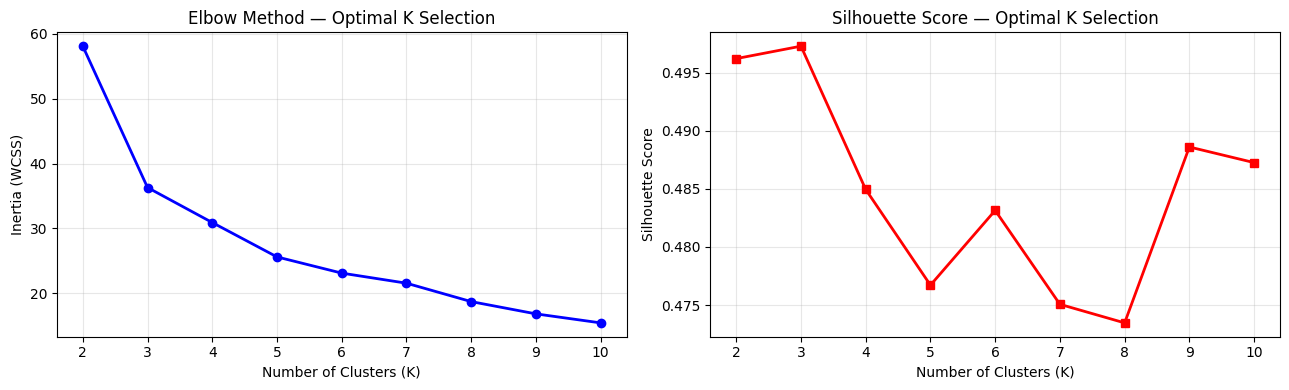


Best K by silhouette score: 3
Silhouette score at K=3: 0.4973


In [13]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

#Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method — Optimal K Selection')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Optimal K Selection')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K by silhouette score: {best_k}")
print(f"Silhouette score at K={best_k}: {max(silhouette_scores):.4f}")

In [14]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

#Find which cluster has the highest average hotspot score
cluster_means = df.groupby('cluster')['hotspot_score'].mean().sort_values(ascending=False)
hotspot_cluster = cluster_means.idxmax()

print("=== CLUSTER SUMMARY ===")
print(f"Number of clusters: {best_k}")
print(f"\nAverage hotspot score per cluster:")
print(cluster_means.round(2))
print(f"\nHotspot cluster (highest avg score): Cluster {hotspot_cluster}")
print(f"\nDistricts per cluster:")
print(df['cluster'].value_counts().sort_index())

#Create binary label for supervised models


=== CLUSTER SUMMARY ===
Number of clusters: 3

Average hotspot score per cluster:
cluster
2    69.94
1    43.85
0    12.77
Name: hotspot_score, dtype: float64

Hotspot cluster (highest avg score): Cluster 2

Districts per cluster:
cluster
0    46
1    77
2    42
Name: count, dtype: int64


In [15]:
#Top 30% of composite score = hotspot
threshold = df['hotspot_score'].quantile(0.70)
df['is_hotspot'] = (df['hotspot_score'] >= threshold).astype(int)

print(f"Threshold (70th percentile score): {threshold:.2f}")
print(f"\nClass distribution:")
print(df['is_hotspot'].value_counts())
print(f"\nHotspot rate: {df['is_hotspot'].mean():.1%}")

Threshold (70th percentile score): 51.88

Class distribution:
is_hotspot
0    115
1     50
Name: count, dtype: int64

Hotspot rate: 30.3%


In [16]:
X_final = X_scaled_df.copy()
y = df['is_hotspot']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.20,
    random_state=42,
    stratify=y #keeps hotspot ratio same in both splits
)

print("=== TRAIN/TEST SPLIT ===")
print(f"Training set: {X_train.shape[0]} districts")
print(f"Test set: {X_test.shape[0]} districts")
print(f"\nTraining hotspot rate: {y_train.mean():.1%}")
print(f"Test hotspot rate: {y_test.mean():.1%}")

=== TRAIN/TEST SPLIT ===
Training set: 132 districts
Test set: 33 districts

Training hotspot rate: 30.3%
Test hotspot rate: 30.3%


In [17]:
#Running GridSearchCV for Random Forest, can take some time
param_grid_rf = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [4, 6, 8, None],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_rf = GridSearchCV(
    rf_base,
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print(f"\nBest parameters: {grid_rf.best_params_}")
print(f"Best CV F1 score: {grid_rf.best_score_:.4f}")


Best parameters: {'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 50}
Best CV F1 score: 0.8645


=== RANDOM FOREST — TEST SET RESULTS ===
Accuracy:      0.9394
Weighted F1:   0.9373
AUC-ROC:       1.0000

Full classification report:
              precision    recall  f1-score   support

 Not Hotspot       0.92      1.00      0.96        23
     Hotspot       1.00      0.80      0.89        10

    accuracy                           0.94        33
   macro avg       0.96      0.90      0.92        33
weighted avg       0.94      0.94      0.94        33



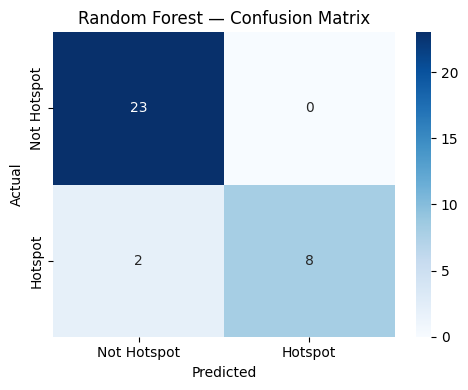

In [18]:
y_pred_rf   = best_rf.predict(X_test)
y_prob_rf   = best_rf.predict_proba(X_test)[:, 1]

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_f1   = f1_score(y_test, y_pred_rf, average='weighted')
rf_auc  = roc_auc_score(y_test, y_prob_rf)

print("=== RANDOM FOREST — TEST SET RESULTS ===")
print(f"Accuracy:      {rf_acc:.4f}")
print(f"Weighted F1:   {rf_f1:.4f}")
print(f"AUC-ROC:       {rf_auc:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Hotspot', 'Hotspot']))

#Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Hotspot', 'Hotspot'],
            yticklabels=['Not Hotspot', 'Hotspot'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

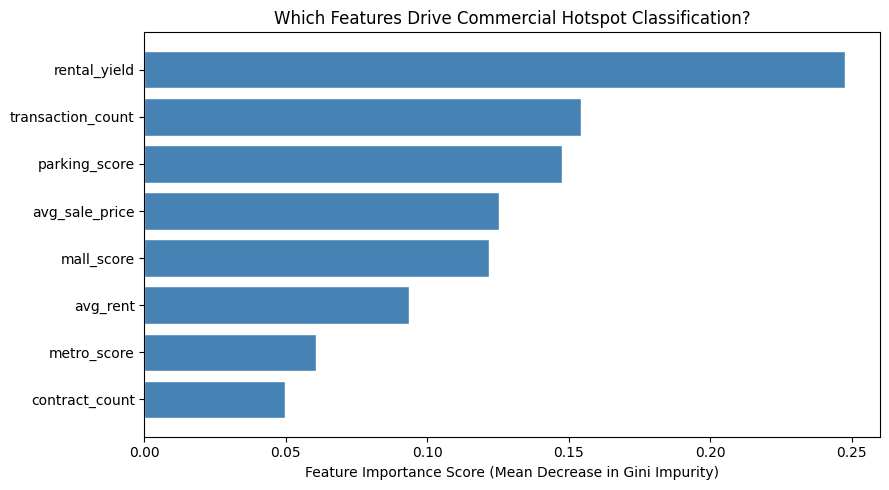


Feature importance ranking:
          Feature  Importance
     rental_yield    0.247612
transaction_count    0.154209
    parking_score    0.147486
   avg_sale_price    0.125153
       mall_score    0.121694
         avg_rent    0.093332
      metro_score    0.060758
   contract_count    0.049756


In [19]:
importances = best_rf.feature_importances_
fi_df = pd.DataFrame({
    'Feature':    features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance Score (Mean Decrease in Gini Impurity)')
plt.title('Which Features Drive Commercial Hotspot Classification?')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importance ranking:")
print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))

In [20]:
#Running GridSearchCV for XGBoost, can take some time

param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth':     [3, 5, 7],
    'n_estimators':  [100, 200, 300],
    'subsample':     [0.8, 1.0]
}

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=pos_weight
)

grid_xgb = GridSearchCV(
    xgb_base,
    param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print(f"\nBest parameters: {grid_xgb.best_params_}")
print(f"Best CV F1 score: {grid_xgb.best_score_:.4f}")


Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 score: 0.8727


=== XGBOOST — TEST SET RESULTS ===
Accuracy:      0.9697
Weighted F1:   0.9692
AUC-ROC:       0.9913

Full classification report:
              precision    recall  f1-score   support

 Not Hotspot       0.96      1.00      0.98        23
     Hotspot       1.00      0.90      0.95        10

    accuracy                           0.97        33
   macro avg       0.98      0.95      0.96        33
weighted avg       0.97      0.97      0.97        33



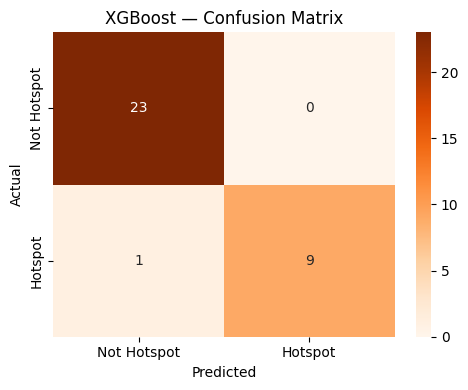

In [21]:
y_pred_xgb  = best_xgb.predict(X_test)
y_prob_xgb  = best_xgb.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb, average='weighted')
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("=== XGBOOST — TEST SET RESULTS ===")
print(f"Accuracy:      {xgb_acc:.4f}")
print(f"Weighted F1:   {xgb_f1:.4f}")
print(f"AUC-ROC:       {xgb_auc:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Hotspot', 'Hotspot']))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Hotspot', 'Hotspot'],
            yticklabels=['Not Hotspot', 'Hotspot'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Compare the two models on the HELD-OUT TEST SET only
print(f"{'Metric':<14}{'Random Forest':>15}{'XGBoost':>12}")
print("-"*41)
for name, rf_v, xgb_v in [('Accuracy',rf_acc,xgb_acc),('Weighted F1',rf_f1,xgb_f1),('AUC-ROC',rf_auc,xgb_auc)]:
    mark_rf  = '  <' if rf_v >  xgb_v else ''
    mark_xgb = '  <' if xgb_v >  rf_v else ''
    print(f"{name:<14}{rf_v:>15.4f}{mark_rf}{xgb_v:>12.4f}{mark_xgb}")

best_model_name = 'Random Forest' if rf_auc >= xgb_auc else 'XGBoost'
best_model      = best_rf if rf_auc >= xgb_auc else best_xgb
print(f"\nSelected model: {best_model_name} (higher test AUC-ROC)")


Metric          Random Forest     XGBoost
-----------------------------------------
Accuracy               0.9394      0.9697  <
Weighted F1            0.9373      0.9692  <
AUC-ROC                1.0000  <      0.9913

Selected model: Random Forest (higher test AUC-ROC)


In [23]:
# Score every district with the selected model (for the dashboard's probability/importance views)
df['predicted_probability'] = best_model.predict_proba(X_final)[:, 1]
df['predicted_hotspot']     = best_model.predict(X_final)

# IMPORTANT: the FINAL RANKING is taken from the transparent survey-weighted score,
# NOT from in-sample model predictions (which would be train/test contaminated).
df['final_rank'] = df['hotspot_score'].rank(ascending=False).astype(int)

final_output = df[['area_id','area_name_en','hotspot_score','predicted_probability',
                   'predicted_hotspot','cluster','final_rank']].sort_values('final_rank').reset_index(drop=True)

print('=== TOP 15 COMMERCIAL OFFICE HOTSPOTS IN DUBAI ===')
print(final_output.head(15).to_string(index=False))

final_output.to_csv('hotspot_rankings.csv', index=False)
df.to_csv('full_results.csv', index=False)


=== TOP 15 COMMERCIAL OFFICE HOTSPOTS IN DUBAI ===
 area_id                      area_name_en  hotspot_score  predicted_probability  predicted_hotspot  cluster  final_rank
     526                      Business Bay     100.000000               0.953341                  1        2           1
     330                       Marsa Dubai      98.813744               0.987443                  1        2           2
     350                  Al Thanyah Fifth      94.528978               0.976353                  1        2           3
     332                    Zaabeel Second      87.466673               0.978877                  1        2           4
     390                      Burj Khalifa      86.160527               0.985457                  1        2           5
     331                     Zaabeel First      85.857635               0.952206                  1        2           6
     441            Al Barsha South Fourth      82.805156               0.959911                  1   